In [1]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [2]:
path_port_serial = "/dev/ttyUSB1"
baudrate = 115200

In [3]:
serial.Serial().reset_input_buffer

<bound method Serial.reset_input_buffer of Serial<id=0x7f87a0322500, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)>

In [4]:
def write(i): 
   l = serial.Serial()
   l.port=path_port_serial
   l.baudrate = baudrate
   l.bytesize = 8
   l.open()
   l.write(b'123')
   l.close()
def read1():
   l = serial.Serial()
   l.port=path_port_serial
   l.baudrate = baudrate
   l.bytesize = 8
   l.open()
   a = l.read(1)[0]
   l.flush()
   l.close()
   return a

In [5]:
import random as rd
import time

In [6]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
#        print(f'{bin(X[i][j])}',end=' ')

        print(f'{X[i][j]:01d}',end=' ')
    print()

In [7]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Bin[i][j] = rd.randint(1*1*(BitsPorSimbolo),1*2**(BitsPorSimbolo))
      Ain[i][j] = rd.randint(1*1*(BitsPorSimbolo),1*2**(BitsPorSimbolo))
  return [Ain,Bin]

In [8]:
create_matrix(4,1)

[array([[1, 2, 1, 2],
        [2, 2, 1, 2],
        [2, 1, 1, 1],
        [2, 2, 1, 1]]),
 array([[2, 1, 1, 1],
        [2, 1, 1, 1],
        [1, 2, 1, 1],
        [2, 2, 1, 1]])]

In [9]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [10]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


In [11]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [12]:
#def send_matrix(X,input,flag,k=0):
#  file = open(f"teste{input}.txt","+w")
#  size = X.shape[0]
#  Y = np.zeros((size,size),dtype=int)
#  fs_fpga2pc_rate = 5e+3
#  fs_pc2fpga_rate = 10e+3
#  s = serial.Serial()
#  s.port = path_port_serial
#  s.baudrate = baudrate
#  s.bytesize = 8
#  #fs_pc2fpga_rate = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop
#
#  s.open()
#  s.write(bytearray([255]))
#  time.sleep(1/fs_pc2fpga_rate)
#  s.write(bytearray([255]))
#  time.sleep(1/fs_pc2fpga_rate)
#  for i in range(X.shape[1]):
#    for j in range(X.shape[0]):
#      s.write(bytearray([X[j][i]]))
#      time.sleep(1/fs_pc2fpga_rate)
#  if(k):
#    s.write(bytearray([0xaa]))
#    time.sleep(1/fs_pc2fpga_rate)
#    s.write(bytearray([0xaa]))
#    time.sleep(1/fs_pc2fpga_rate)
#  else:
#    s.write(bytearray([0xaa]))
#    time.sleep(1/fs_pc2fpga_rate)
#    s.write(bytearray([0xaa]))
#    time.sleep(1/fs_pc2fpga_rate)
#    #for i in range(size):
#    #  for j in range(size):
#    #    #Y[i][j] = s.read()[0]
#    #    time.sleep(1/fs_fpga2pc_rate)
#  
#  s.close()  
#  s.close()  
#  return Y
 

In [13]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
M

[array([[2, 1, 1, 2],
        [1, 1, 1, 2],
        [1, 2, 2, 2],
        [1, 1, 1, 1]]),
 array([[1, 2, 2, 1],
        [1, 2, 2, 2],
        [2, 1, 2, 1],
        [2, 2, 2, 1]])]

In [14]:
M_p = shiftMatrixSystolic(M[0],M[1])

In [15]:
M_p

[array([[0, 0, 0, 2, 1, 1, 2],
        [0, 0, 1, 1, 1, 2, 0],
        [0, 1, 2, 2, 2, 0, 0],
        [1, 1, 1, 1, 0, 0, 0]]),
 array([[0, 0, 0, 1, 1, 2, 2],
        [0, 0, 2, 2, 1, 2, 0],
        [0, 2, 2, 2, 2, 0, 0],
        [1, 2, 1, 1, 0, 0, 0]])]

In [16]:
#for i in range(1):
#    print("Matriz -----------------------",i,"--------------------------")
#    #print(M[0]@M[1])
#    #M = create_matrix(Din = 16, BitsPorSimbolo=np.log2(1))
#    M_p = shiftMatrixSystolic(M[0],M[1])
#    send_matrix(M_p[0],"Iquantidade_de_opPUT_A1",1,k=1)
#    send_matrix(M_p[1],"Iquantidade_de_opPUT_B1",1,k=0)
#    #rec_matrix(4)
#    #rec_matrix(M[0].shape[0])
#    print(M[0]@M[1])
#    print(0)
#    time.sleep(10)


## Representação do problema 
         OPA   OPB
 ....f000776af000776a_f000776a0f00776....
 ....f001370af001370a_f001370a0f01370....
 ....f031100af031100a_f031100a0f31100....
 ....f193000af193000a_f193000a1f93000....



In [17]:
def send_matrix_rec(X,input,fs_pc2fpga_rate):
  file = open(f"teste{input}.txt","+w")
   
  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = baudrate
  s.bytesize = 8

  #fs_pc2fpga_rate = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop
  s.open()
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xff]))
  time.sleep(1/fs_pc2fpga_rate)
  for i in range(X.shape[1]):
    conc = 0
    for j in range(X.shape[0]):
      s.write(bytearray([X[j][i]]))
      conc += X[j][i]*pow(10,j)
      time.sleep(1/fs_pc2fpga_rate)
    if(fs_pc2fpga_rate <10):
      strr = str(conc)[::-1]
      print(f'{strr}',"\n")
  s.write(bytearray([0xad]))
  time.sleep(1/fs_pc2fpga_rate)
  s.write(bytearray([0xda]))
  time.sleep(1/fs_pc2fpga_rate)
  #if(k):
    #for i in range(size):
    #  for j in range(size):
    #    #Y[i][j] = s.read()[0]
    #    print(s.read()[0])
    #    #time.sleep(1/(fs_fpga2pc_rate))
    #s.close()
    #while(True):
    #  print(s.read()[0])  
    #  time.sleep(1/(fs_fpga2pc_rate))
  s.close()  

 

In [18]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
M

[array([[2, 2, 1, 1],
        [2, 2, 1, 1],
        [1, 2, 2, 1],
        [2, 1, 1, 1]]),
 array([[1, 1, 1, 1],
        [2, 1, 2, 2],
        [2, 2, 1, 1],
        [2, 2, 1, 2]])]

In [19]:
M[0].shape[1]

4

In [20]:
M[0].shape[0]

4

In [21]:
def transmitter_uart(M,fs_pc2fpga_rate):
    M_p = shiftMatrixSystolic(M[0],M[1])
    send_matrix_rec(M_p[0],"Iquantidade_de_opPUT_A1",fs_pc2fpga_rate)
    send_matrix_rec(M_p[1],"Iquantidade_de_opPUT_B1",fs_pc2fpga_rate)

In [22]:
def receiver_uart(size):
    s = serial.Serial()
    s.port = path_port_serial
    s.baudrate = baudrate
    s.bytesize = 8
    #s.timeout = .5#(size**2+2)/baudrate
    s.open()
    Y= np.zeros((size,size),dtype=int)
    i = 0

    index_row = 0
    index_col = 0
    flag =0
    s.write(bytearray([0xea]))
    s.write(bytearray([0xea]))
    a = s.read()
    print(a)
    #if(a != 239 and a != 254):
    #    return Y
    while(True):
        try:
            a = s.read()[0]
        except IndexError:
            print("Matriz corrompida...")
            return Y
        if(a==b''):
            print("Vazio")
            return Y
        if(a!=0 and a!=254 and a!=239 and a!= 255):

            i+=1
            Y[index_row][index_col] = a
            index_col +=1
            if(index_col == size):
                index_row +=1
                if(index_col == size-1 and index_row == size-1):
                    flag = 1
                    break
                index_col = 0
        if(i == size**2 or flag ):
            break


        #if(a==0):
        #    break
    s.close()
    return Y

In [23]:
def receiver_uart_linear(size):
    fpga2pc_rate = 10472
    s = serial.Serial()
    s.port = path_port_serial
    s.baudrate = baudrate
    s.bytesize = 8
    s.open()
    Y= np.zeros((size*size),dtype=int)
    i = 0
    while(True):
        if(i==0):
            s.write(bytearray([0xea]))
            s.write(bytearray([0xea]))
        a = s.read()[0]
        if(a!=0 and a!=254 and a!=239):
            Y[i] = a
            print(a)
            i+=1
        if(i == size**2):
            break


        #if(a==0):
        #    break
    s.close()
    return Y

In [24]:
def receiver_uart(size):
    s = serial.Serial()
    s.port = path_port_serial
    s.baudrate = baudrate
    s.bytesize = 8
    s.timeout = 5#(size**2+2)/baudrate
    s.open()
    Y= np.zeros((size,size),dtype=int)
    i = 0

    index_row = 0
    index_col = 0
    flag =0
    s.write(bytearray([0xea]))
    s.write(bytearray([0xea]))
    a = s.read()
    #print(a)
    #if(a != 239 and a != 254):
    #    return Y
    while(True):
        try:
            a = s.read()[0]
            #print(a)
        except IndexError:
            print("Matriz corrompida...")
            return Y
        if(a==b''):
            print("Vazio")
            return Y
        if(a!=0 and a!=254 and a!=239 and a!= 255):

            i+=1
            Y[index_row][index_col] = a
            index_col +=1
            if(index_col == size):
                index_row +=1
                if(index_col == size-1 and index_row == size-1):
                    flag = 1
                    break
                index_col = 0
        if(i == size**2 or flag ):
            break


        #if(a==0):
        #    break
    s.close()
    return Y

In [25]:
print(0xfe,0xef)

254 239


In [26]:
def compar_matrix(M1,M2):
    for i in range(M1.shape[0]):
        for j in range(M1.shape[0]):
            if(M1[i][j]!=M2[i][j]):
                return 1
    return 0

In [27]:
import os 
from IPython.display import clear_output

#  Dashboard Métricas de acertos e erros

In [28]:

def torneio(taxa_de_transferencia,quantidade_de_op,dimensao_das_matrizes):
    ZEROS = np.zeros((dimensao_das_matrizes,dimensao_das_matrizes))
    fail =0
    operandos_corrompidos= 0
    for i in range(quantidade_de_op+1):
        time.sleep(((80*(dimensao_das_matrizes**2)))/baudrate)


        clear_output(wait=True)
        print("-"*100," 100%")
        print("-"*int(100*(((i+1)/quantidade_de_op))),(i*100)/quantidade_de_op,"%")

        M = create_matrix(Din =dimensao_das_matrizes, BitsPorSimbolo=1)
        try:
            print(f"Taxa de Transferencia =  {taxa_de_transferencia:} ",f'{(i/quantidade_de_op)*100:3.2f}',"/",1*100, "| fail: ", fail,"|Pass: ",i-fail, " |Pass(%): ",f'{((i-fail)/(i))*100:.2f}'," |Operandos Corrompidos: ",operandos_corrompidos)
        except ZeroDivisionError:
            print(f"Taxa de Transferencia =  {taxa_de_transferencia:} ",f'{(i/quantidade_de_op)*100:3.2f}',"/",1*100, "| fail: ", fail,"|Pass: ",i-fail, " |Pass(%): ",f'{((i-fail)/(1))*100:.2f}'," |Operandos Corrompidos: ",operandos_corrompidos)

        X =M[0]@M[1]
        print("\nCalculo de Referencia: PC")
        #print_matrix(X)
        transmitter_uart(M,taxa_de_transferencia)
        #time.sleep(1)
        time.sleep(((10*(dimensao_das_matrizes**2)))/baudrate)
        #time.sleep(2)
        Y = receiver_uart(dimensao_das_matrizes)
        print("\nCalculo obtido: FPGA")
        #print_matrix(Y)
        plt.imshow(X)
        plt.imshow(Y)
        plt.show()
        cmp = compar_matrix(X,Y)
        operandos_corrompidos_cpm = compar_matrix(Y,ZEROS)
        if(cmp):
            fail+=1
            #return M
            #break

        if(not(operandos_corrompidos_cpm)):
            operandos_corrompidos +=1

        print("\n\n Falha" if cmp else "\n\n Sucesso",end='\n')

    return ((quantidade_de_op-fail)/(quantidade_de_op))*100,(operandos_corrompidos/quantidade_de_op)*100

----------------------------------------------------------------------------------------------------  100%
 0.169 %
Taxa de Transferencia =  115200.0  0.17 / 100 | fail:  1 |Pass:  168  |Pass(%):  99.41  |Operandos Corrompidos:  0

Calculo de Referencia: PC

Calculo obtido: FPGA


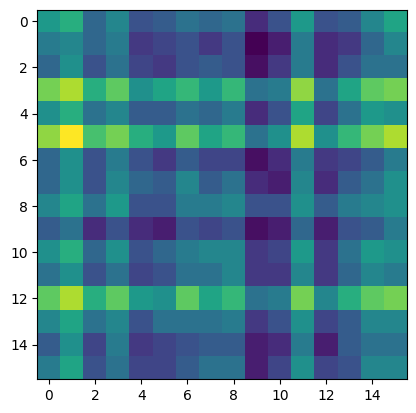



 Sucesso


KeyboardInterrupt: 

In [29]:
torneio(taxa_de_transferencia=115.2e+3,quantidade_de_op=100000,dimensao_das_matrizes=16)

In [ ]:
print(64 - 64)
print(67 - 67)
print(75 - 75)
print(72 - 72)
print(72 - 73)
print(67 - 67)
print(70 - 70)
print(67 - 67)
print(95 - 71)
print(60 - 60)
print(50 - 50)
print(54 - 54)
print(47 - 63)
print(68 - 68)
print(82 - 66)
print(62 - 62)

0
0
0
0
-1
0
0
0
24
0
0
0
-16
0
16
0


In [ ]:
def receiver_uart(size):
    s = serial.Serial()
    s.port = path_port_serial
    s.baudrate = baudrate
    s.bytesize = 8
    #s.timeout = .01#(size**2+2)/baudrate
    s.open()
    Y= np.zeros((size,size),dtype=int)
    i = 0

    index_row = 0
    index_col = 0
    flag =0
    s.write(bytearray([0xea]))
    s.write(bytearray([0xea]))
    s.reset_input_buffer()
    
    a = s.read()

    #if(a != 239 and a != 254):
    #    return Y
    while(True):
        a = s.read()[0]
        i+=1


        if(a!=0 and a!=b'' and a!=254 and a!=239 and a!= 255):
            print(a)
#
        #    i+=1
        #    Y[index_row][index_col] = a
        #    index_col +=1
        #    if(index_col == size):
        #        index_row +=1
        #        if(index_col == size-1 and index_row == size-1):
        #            flag = 1
        #            break
        #        index_col = 0
        #if(i == size**2 or flag ):
        #    break


        #if(a==0):
        #    break
    s.close()
    return Y

In [ ]:
A,B=        create_matrix(Din =16, BitsPorSimbolo=2)


In [ ]:
transmitter_uart((A,B),1000)
time.sleep(1)
#time.sleep(((100*(dimensao_das_matrizes**2)))/baudrate)
#Y = receiver_uart(100)

In [ ]:
receiver_uart(16)

b''


KeyboardInterrupt: 

In [ ]:
torneio(taxa_de_transferencia=100,quantidade_de_op=100,dimensao_das_matrizes=8)

----------------------------------------------------------------------------------------------------  100%
- 0.0 %
Taxa de Transferencia =  100  0.00 / 100 | fail:  0 |Pass:  0  |Pass(%):  0.00  |Operandos Corrompidos:  0

Calculo de Referencia: PC
32 41 41 28 37 32 35 45 
34 42 40 26 36 34 35 42 
37 40 37 28 41 31 35 44 
27 38 40 27 32 30 31 39 
30 38 40 28 36 29 35 44 
34 43 39 26 35 34 33 40 
25 34 33 21 30 27 25 34 
28 32 28 20 28 24 27 32 


KeyboardInterrupt: 

In [ ]:

pontos = []
freqs = []
corrompidos = []
for i in range(1000,16000,2000):
    acertos,operandos_corrompidos = torneio(taxa_de_transferencia=i,quantidade_de_op=100,dimensao_das_matrizes=4)
    pontos.append(acertos)
    corrompidos.append(operandos_corrompidos)
    freqs.append(i)


----------------------------------------------------------------------------------------------------  100%
----------------------------------------------------------------------------------------------------- 100.0 %
Taxa de Transferencia =  15000  100.00 / 100 | fail:  35 |Pass:  65  |Pass(%):  65.00  |Operandos Corrompidos:  3

Calculo de Referencia: PC
10 10 13 11 
7 7 9 8 
7 7 9 8 
10 10 13 11 

Calculo obtido: FPGA
10 10 13 11 
7 7 9 8 
7 7 9 8 
10 10 13 11 


 Sucesso


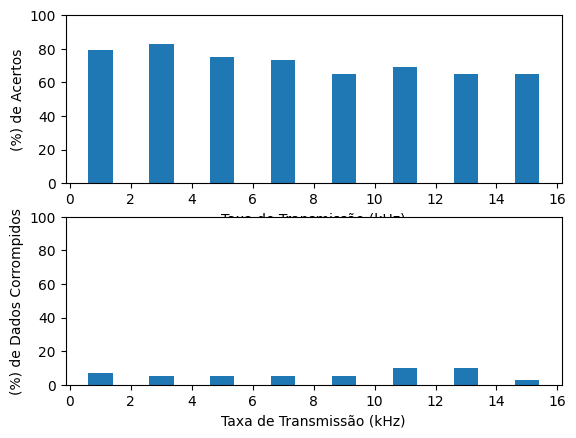

In [ ]:
plt.subplot(2,1,1)

plt.xlabel("Taxa de Transmissão (kHz)")
plt.ylabel("(%) de Acertos")
plt.bar(np.array(freqs)/1000,pontos)
plt.ylim((0,100))
plt.subplot(2,1,2)
plt.ylim((0,100))
plt.bar(np.array(freqs)/1000,corrompidos)

plt.xlabel("Taxa de Transmissão (kHz)")
plt.ylabel("(%) de Dados Corrompidos")
plt.show()
#plt.xlim((-1000,10000))

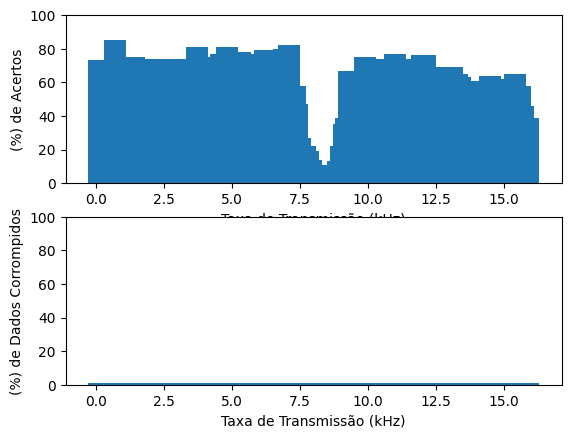

In [ ]:
plt.subplot(2,1,1)

plt.xlabel("Taxa de Transmissão (kHz)")
plt.ylabel("(%) de Acertos")
plt.bar(np.array(freqs)/1000,pontos)
plt.ylim((0,100))
plt.subplot(2,1,2)
plt.ylim((0,100))
plt.bar(np.array(freqs)/1000,corrompidos)

plt.xlabel("Taxa de Transmissão (kHz)")
plt.ylabel("(%) de Dados Corrompidos")
plt.show()
#plt.xlim((-1000,10000))

Text(0, 0.5, '(%) de Acertos')

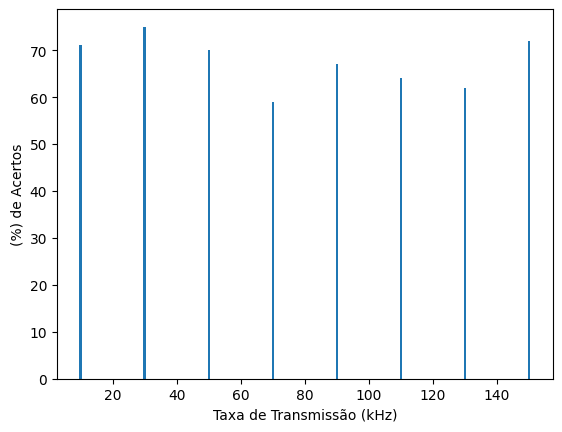

In [ ]:

plt.bar(np.array(freqs)/100,pontos)
plt.xlabel("Taxa de Transmissão (kHz)")
plt.ylabel("(%) de Acertos")
#plt.xlim((-1000,10000))

In [ ]:
for i in range(len(pontos)):
    print(f'{pontos[i]:.1f} ,   {freqs[i]:.1f}  ,   {i}')

71.0 ,   1000.0  ,   0
75.0 ,   3000.0  ,   1
70.0 ,   5000.0  ,   2
59.0 ,   7000.0  ,   3
67.0 ,   9000.0  ,   4
64.0 ,   11000.0  ,   5
62.0 ,   13000.0  ,   6
72.0 ,   15000.0  ,   7


In [ ]:
transmitter_uart(M, 1e+3)
Y = receiver_uart(M[0].shape[0])

In [ ]:
M = create_matrix(Din =4, BitsPorSimbolo=2)
transmitter_uart(M, 10e+3)
time.sleep(1)
Y = receiver_uart(M[0].shape[0])
print_matrix(M[0]@M[1])
print('\n')
print_matrix(Y)

28 35 46 36 
25 31 38 30 
34 41 53 41 
30 36 44 37 


28 35 46 36 
25 31 38 30 
34 41 53 41 
30 36 44 37 


In [ ]:
print_matrix(X)
print('\n')
print_matrix(Y)

NameError: name 'X' is not defined

In [ ]:
str("1000")[::-1]

: 

: 

In [ ]:
X

: 

In [ ]:
Y

: 

In [ ]:
for i in range(100):
    print("Matriz -----------------------",i,"--------------------------")
    #print(M[0]@M[1]) 
    M = create_matrix(Din =4, BitsPorSimbolo=2)
    X =M[0]@M[1]
    transmitter_uart(M,10e+3)
    time.sleep(1)#Representação do Atraso para calcular
    Y = receiver_uart(M[0].shape[0])
    #print("\nAlvo: PC")
    #print_matrix(X)
    #print("\nObtido: FPGA ")
    #print_matrix(Y)
    if(compar_matrix(X,Y)):
        print('Fail:')
        print("\nAlvo: PC")
        print_matrix(X)
        print("\nObtido: FPGA ")
        print_matrix(Y)       
        break
    else:
        print("Pass")
    ###time.sleep(1)# 10.472kHz


: 

In [ ]:
for i in range(1000):
    print("Matriz -----------------------",i,"--------------------------")
    #print(M[0]@M[1])
    M = create_matrix(Din =4, BitsPorSimbolo=np.log2(2))
    X =M[0]@M[1]
    transmitter_uart(M)
    #time.sleep(1)#Representação do Atraso para calcular
    Y = receiver_uart(M[0].shape[0])
    print("\nAlvo: PC")
    print_matrix(X)
    print("\nObtido: FPGA ")
    print_matrix(Y)
    time.sleep(1)


: 

In [ ]:
#for i in range(100):
#    arq = open("OUT.txt","+a")
#    #M = create_matrix(Din =4, BitsPorSimbolo=np.log2(2))
#    X =M[0]@M[1]
#    transmitter_uart(M,fs_pc2fpga_rate=1e+3)
#    #time.sleep(1)#Representação do Atraso para calcular
#    #time.sleep(5)
#    Y = receiver_uart(M[0].shape[0])
#    print("\nAlvo: PC")
#    print_matrix(X)
#    plt.subplot(2,1,1)
#    #plt.imshow(X)
#    print("\nObtido: FPGA ")
#    print_matrix(Y)
#    #plt.subplot(2,1,1)
#    plt.imshow(Y)
#    plt.show(0)
#    #for i in range(X.shape[0]):
#    #    for j in range(X.shape[0]):
#    #        arq.write(str(X[i][j]))
#    #arq.write("\n")
#    for i in range(X.shape[0]):
#        for j in range(X.shape[0]):
#            arq.write(str(Y[i][j]))
#    arq.write("\n")
#    arq.close()
#    time.sleep(3)

: 

In [ ]:
print_matrix(X)
print('\n')
print_matrix(Y)

: 

In [ ]:
plt.subplot(2,1,1)
plt.imshow(X)
plt.subplot(2,1,2)
plt.imshow(Y)

: 

In [ ]:
plt.imshow(X)
plt.imshow(Y)

: 

In [ ]:
receiver_uart_linear(M[0].shape[0])

: 

In [ ]:
a = b'\x11'
int(hex(int(a[0]))[2:])


: 

In [ ]:
for i in range(2):
    print("Matriz -----------------------",i,"--------------------------")
    #M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
    M_p = shiftMatrixSystolic(M[0],M[1])
    print(M[0]@M[1])
    send_matrix(M_p[0],"Iquantidade_de_opPUT_A1",1,k=1)
    send_matrix(M_p[1],"Iquantidade_de_opPUT_B1",1,k=0)
    
    #time.sleep(10)


: 

In [ ]:
M[0]

: 

In [ ]:
M[1]

: 

In [ ]:
M[0]@M[1]

: 

In [ ]:
M[1]@M[0]

: 

In [ ]:
plt.imshow(M[1])

: 

In [ ]:
plt.imshow(M[0])

: 

In [ ]:
M[0]@M[1]

: 

M_p = shiftMatrixSystolic(M[0],M[1])

In [ ]:
M[1]@M[0]

: 

: 

In [ ]:
M[0]@M[1]

: 

In [ ]:
M_p = shiftMatrixSystolic(M[0],M[0])
M_p[0],M_p[1]

: 

In [ ]:
M = create_matrix(Din = 16, BitsPorSimbolo=1)

In [ ]:
M[0]@M[1]

: 

In [ ]:
M

: 

In [ ]:
M_p[0]

: 

In [ ]:
M_p[1]

: 

: 

In [ ]:
def send_matrix1(X,input,flag):
  file = open(f"../teste{input}.mem","+w")
  #file.write(f"assign {input}[{0}] = "+"32'"+"h"+str("ffffffff")+";\n")
  k = 0
  file.write(f'{0XFF:02X}'+"\n")
  file.write(f'{0XFF:02X}'+"\n")
  for i in range(X.shape[1]):
    strbin = 0
    for j in range(X.shape[0]):
        file.write(f'{X[j][i]:02d}'+"\n")
        #file.write(f"assign {input}[{k:03}] = "+"8'"+"h"+f'{X[j][i]:02d}'+";\n")
        k =k+1
        #strbin+= int(X[j][i]*pow(10,X.shape[0]-1-j))
    #print(f'{strbin:016d}',i)
   # print(int('0b'+strbin,2))
   # file.write(f"assign {input}[{i+1}] = "+"32'"+"h"+f'{strbin:08d}'+";\n")
  #file.close()
  file.write(f'{0XAD:02X}'+"\n")
  file.write(f'{0XDA:02X}'+"\n")
for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix1(M_p[0],"INPUT_A1",0)
    send_matrix1(M_p[1],"INPUT_B1",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


In [ ]:
M[0]@M[1]

array([[61, 61, 58, 56, 72, 63, 68, 67, 67, 62, 60, 55, 67, 55, 61, 66],
       [76, 86, 77, 66, 93, 89, 81, 84, 86, 76, 70, 67, 86, 77, 78, 82],
       [70, 70, 64, 65, 84, 72, 77, 71, 76, 70, 68, 63, 75, 74, 70, 71],
       [64, 68, 70, 64, 86, 71, 81, 76, 76, 67, 67, 62, 79, 65, 66, 74],
       [63, 67, 62, 55, 73, 70, 71, 70, 66, 64, 57, 59, 74, 61, 63, 70],
       [59, 67, 66, 58, 80, 71, 69, 74, 73, 60, 60, 58, 75, 62, 55, 65],
       [65, 64, 64, 56, 81, 65, 76, 73, 76, 65, 61, 60, 71, 62, 64, 67],
       [63, 63, 57, 53, 71, 63, 66, 66, 65, 61, 60, 53, 63, 62, 63, 64],
       [65, 66, 63, 61, 79, 71, 73, 69, 67, 63, 63, 58, 69, 68, 63, 67],
       [75, 76, 76, 69, 96, 81, 88, 85, 88, 73, 75, 69, 84, 72, 75, 79],
       [66, 69, 69, 58, 81, 71, 72, 76, 77, 67, 61, 65, 78, 65, 67, 70],
       [49, 49, 44, 41, 58, 55, 53, 53, 53, 46, 45, 42, 52, 49, 49, 51],
       [66, 73, 64, 59, 80, 72, 72, 76, 77, 63, 68, 63, 74, 67, 63, 68],
       [62, 69, 61, 56, 76, 68, 71, 75, 74, 63, 64,

In [ ]:
print_matrix(M_p[0])
plt.imshow(M_p[0])

: 

In [ ]:
M[0]@M[1]

: 

In [ ]:
M_p[1]

: 

In [ ]:
M_p[0]

: 

In [ ]:
print_matrix(M[0]@M[1])

: 

In [ ]:
M[0]@M[1]

: 

In [ ]:
shiftMatrixSystolic(M[0],M[1])

: 

In [ ]:
plt.imshow(M[0]@M[1])

plt.show()

: 

: 

In [ ]:

#for i in range(100):
#    print("----------------------",i,"--------------------------")
#    M_p = shiftMatrixSystolic(M[0],M[1])
#    #Bin = M[1]
#    send_matrix(M_p[0],"Iquantidade_de_opPUT_A1",0)
#    send_matrix(M_p[1],"Iquantidade_de_opPUT_B1",0)
#    
#    break
#    time.sleep(10)
#
#send_matrix(Bin)

: 

In [ ]:
M[0]

: 

In [ ]:
M[1]

: 

In [ ]:
M[0]@M[1]

: 

In [ ]:
s = serial.Serial()

s.port = path_port_serial
s.baudrate = baudrate
s.bytesize = 8
s.close()
s.open()

: 

In [ ]:
i =1
s.write(bytearray([int(i)]))


: 

In [ ]:
serial.Serial()

: 